# EDA — Batter Decision Value v4

Characterises six seasons of Statcast data (2021–2026) before any modelling.
Each section ends with the decision it settles; those decisions feed
`IMPROVEMENT_PLAN.md`.

All loading, cleaning and the 2026 harmonization live in `src/data.py` so the
rules exist in exactly one place.

In [1]:
import sys; sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data as D

pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')
SEASONS = range(2021, 2027)
PALETTE = ['#FFB000', '#648FFF', '#785EF0', '#DC267F', '#FE6100', '#3D1EB2']

In [2]:
raw = pd.concat([pd.read_parquet(D.CACHE_DIR / f'{y}.parquet') for y in SEASONS], ignore_index=True)
df = D.add_zone_frame(D.clean(D.to_middle_of_plate(raw), verbose=True))
print(f'\nanalysis frame: {len(df):,} rows')

4,237,650 rows in
  -   13,872  non-decision (auto ball/strike)
  -    2,057  no tracked location
  -       44  no trajectory
  -       31  no delta_run_exp
  -       53  in-play with unmapped event
 4,221,593  kept



analysis frame: 4,221,593 rows


## §1 Integrity and coverage

**Decides:** the exclusion list, and whether the ~0.4% of pitches with no
tracked location can simply be dropped.

In [3]:
g = raw.groupby('season')
summary = pd.DataFrame({
    'pitches': g.size(),
    'first': g.game_date.min().dt.date,
    'last': g.game_date.max().dt.date,
    'games': g.game_pk.nunique(),
    'batters': g.batter.nunique(),
    'game_types': g.game_type.apply(lambda s: ','.join(sorted(s.astype(str).unique()))),
})
summary

,pitches,first,last,games,batters,game_types
season,,,,,,
2021,712320,2021-04-01,2021-10-03,2429,1049,R
2022,710210,2022-04-07,2022-10-05,2430,693,R
2023,719391,2023-03-30,2023-10-01,2426,656,R
2024,709969,2024-03-28,2024-09-30,2423,651,R
2025,711897,2025-03-27,2025-09-28,2428,673,R
2026,673863,2026-03-25,2026-09-16,2283,659,R


In [4]:
# Missingness of the fields the model depends on.
fields = ['plate_x', 'plate_z', 'sz_top', 'sz_bot', 'vx0', 'ay', 'delta_run_exp',
          'release_speed', 'pfx_x', 'pitch_type', 'zone', 'events', 'launch_speed', 'bat_speed']
miss = raw.groupby('season')[fields].apply(lambda g: g.isna().mean() * 100).T.round(2)
print('% missing by season')
miss

% missing by season


season,2021,2022,2023,2024,2025,2026
plate_x,0.43,0.29,0.42,0.38,0.37,0.38
plate_z,0.43,0.29,0.42,0.38,0.37,0.38
sz_top,0.43,0.29,0.42,0.38,0.37,0.38
sz_bot,0.43,0.29,0.42,0.38,0.37,0.38
vx0,0.40,0.29,0.39,0.36,0.36,0.38
ay,0.40,0.29,0.39,0.36,0.36,0.38
delta_run_exp,0.35,0.24,0.38,0.34,0.34,0.33
release_speed,0.40,0.29,0.39,0.36,0.36,0.38
pfx_x,0.40,0.30,0.39,0.36,0.38,0.38
pitch_type,0.40,0.29,0.42,0.38,0.37,0.38


In [5]:
# Every description value, and whether the taxonomy covers it.
tab = raw.pivot_table(index='description', columns='season', values='game_pk',
                      aggfunc='size', observed=True).fillna(0).astype(int)
tab['handling'] = ['decision' if i in D.DESCRIPTION_MAP else
                   ('excluded: non-decision' if i in D.NON_DECISION else 'UNMAPPED')
                   for i in tab.index]
tab.sort_values('handling')

season,2021,2022,2023,2024,2025,2026,handling
description,,,,,,,
ball,236921,235203,240211,235146,237986,226724,decision
blocked_ball,17316,16060,15880,14953,15122,14007,decision
bunt_foul_tip,41,24,16,16,33,27,decision
called_strike,116618,115882,117737,115918,115487,108793,decision
foul,125997,127216,127727,128360,127268,121296,decision
foul_bunt,1569,1111,1001,1232,1245,1439,decision
foul_pitchout,1,0,0,0,0,0,decision
foul_tip,6732,7008,7248,7325,7297,7051,decision
hit_by_pitch,2112,2046,2107,2009,1927,1995,decision


In [6]:
# Duplicate pitches, and confirmation that the fetch filters held.
key = ['game_pk', 'at_bat_number', 'pitch_number']
dupes = raw.duplicated(subset=key).sum()
print(f'duplicate (game_pk, at_bat, pitch): {dupes:,}')
print(f'game_type values: {sorted(raw.game_type.astype(str).unique())}')

# The overseas exclusion should already have removed these game_pks.
overseas = pd.concat([D.game_venues(y).assign(season=y) for y in SEASONS])
overseas = overseas[~overseas.country.isin(D.KEEP_COUNTRIES)]
leaked = raw.game_pk.isin(set(overseas.game_pk)).sum()
print(f'overseas pitches surviving the fetch filter: {leaked:,}  (want 0)')
print(overseas.groupby(['season', 'country']).size().to_string())

duplicate (game_pk, at_bat, pitch): 0
game_type values: ['R']


overseas pitches surviving the fetch filter: 0  (want 0)
season  country          
2023    Mexico               2
        United Kingdom       2
2024    Mexico               2
        Republic of Korea    2
        United Kingdom       2
2025    Japan                2
2026    Mexico               2


**§1 findings.** Location, strike-zone bounds and trajectory go missing
together on the same ~0.3–0.4% of pitches — untracked pitches, not a
field-specific defect — so dropping them is safe and unbiased with respect to
the decision. `events` is ~74% null and `launch_speed` ~67% null by
construction (PA-ending pitches and balls in play respectively). `bat_speed`
exists only from 2024, so it can serve as a *prior-season* hitter feature for
2025–2026 and nothing earlier.

`automatic_ball` and `automatic_strike` are intentional walks (pre-2023) and
pitch-clock violations (2023+). No pitch is thrown that the batter could judge,
so they are excluded as non-decisions — explicitly, and counted, rather than
dropped by a silent `dropna` as in v3.

## §2 Pitchers batting

**Decides:** the pitcher-batting filter, and whether 2021 is usable for
hitter-level features.

In [7]:
pa = (raw.groupby(['season', 'batter'])['at_bat_number'].nunique()
        .rename('pa').reset_index())
pitchers = raw.groupby('season')['pitcher'].apply(lambda s: set(s.unique()))
pa['also_pitches'] = [b in pitchers[s] for s, b in zip(pa.season, pa.batter)]

rows = []
for s, g in pa.groupby('season'):
    sus = g[g.also_pitches & (g.pa < 50)]
    rows.append({'season': s, 'batters': len(g), 'pitcher-batters': len(sus),
                 'their PAs': int(sus.pa.sum()), 'median PA (all)': int(g.pa.median())})
pd.DataFrame(rows).set_index('season')

,batters,pitcher-batters,their PAs,median PA (all)
season,,,,
2021,1049,402,3417,38
2022,693,18,490,71
2023,656,18,489,74
2024,651,19,571,74
2025,673,30,744,71
2026,659,16,445,71


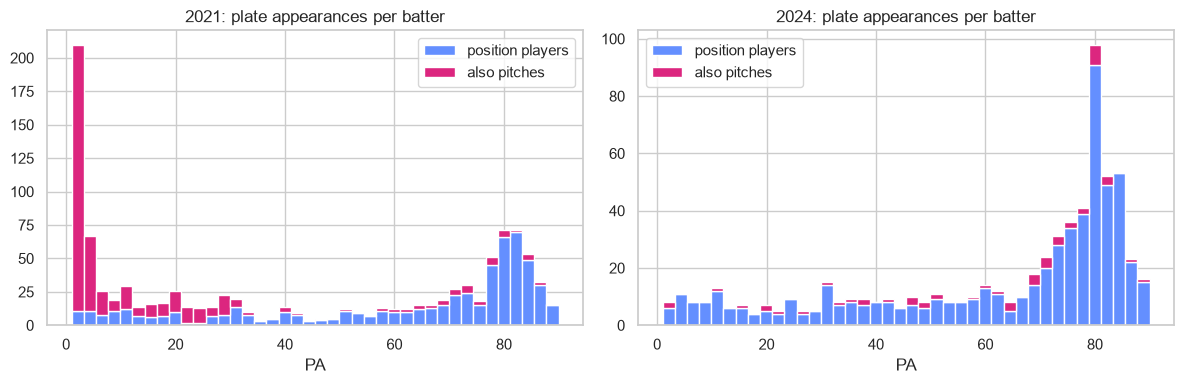

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, s in enumerate([2021, 2024]):
    sub = pa[pa.season == s]
    ax[i].hist([sub[~sub.also_pitches].pa, sub[sub.also_pitches].pa], bins=40, stacked=True,
               label=['position players', 'also pitches'], color=[PALETTE[1], PALETTE[3]])
    ax[i].set_title(f'{s}: plate appearances per batter'); ax[i].set_xlabel('PA'); ax[i].legend()
fig.tight_layout()

**§2 findings.** 2021 carries several hundred batters who also pitch and take
very few plate appearances — NL pitchers hitting, before the universal DH
arrived in 2022. They drag the median balls-in-play per batter down sharply and
would pollute both the league models and any per-hitter feature.

`D.drop_pitchers_batting()` removes a batter who also appears as a pitcher that
season *and* takes fewer than 50 PAs, which keeps genuine two-way players.
2022 onward needs no filter, but it is applied uniformly so the seasons stay
comparable.

## §3 Target construction

**Decides:** the target definition, and whether the run-value table can be
fitted once or needs to be era-specific.

In [9]:
# Is delta_run_exp a deterministic base-out-count lookup, or does it carry
# pitch-level information? Mid-PA balls only, so nothing else can vary.
m = raw[(raw.description == 'ball') & (raw.balls < 3)].copy()
for c in ('on_1b', 'on_2b', 'on_3b'):
    m[c] = m[c].notna()
grp = m.groupby(['season', 'balls', 'strikes', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b'],
                observed=True)['delta_run_exp'].agg(['std', 'mean', 'size']).query('size >= 30')
print(f'groups: {len(grp):,}')
print(f'within-group std  -- median {grp["std"].median():.8f}, 99th pct {grp["std"].quantile(.99):.6f}')
print(f'group means span  -- {grp["mean"].min():+.4f} .. {grp["mean"].max():+.4f} runs')

groups: 1,253
within-group std  -- median 0.00000000, 99th pct 0.037361
group means span  -- -0.0350 .. +0.2130 runs


In [10]:
# How much does averaging over base-out states cost? Spread of delta_run_exp
# within each (outcome, count) cell.
spread = (df.groupby(['outcome', 'count'], observed=True)['delta_run_exp']
            .agg(['mean', 'std', 'size']).query('size >= 500'))
print('std of delta_run_exp within (outcome, count), i.e. what the target averages away:')
print(spread.groupby('outcome')['std'].median().sort_values(ascending=False).round(4).to_string())

std of delta_run_exp within (outcome, count), i.e. what the target averages away:
outcome
home_run           0.5254
triple             0.1711
double             0.1050
single             0.1001
hit_by_pitch       0.0942
field_error        0.0675
field_out          0.0624
ball               0.0213
swinging_strike    0.0154
called_strike      0.0148
foul               0.0116


In [11]:
# Drift: is a called strike on 0-2 worth the same in 2021 and 2026?
per_season = (df.groupby(['season', 'outcome', 'count'], observed=True)['delta_run_exp']
                .mean().unstack('season'))
watch = [('called_strike', '0-2'), ('called_strike', '3-0'), ('ball', '3-0'),
         ('ball', '0-0'), ('home_run', '0-0'), ('field_out', '0-0')]
drift = per_season.loc[[w for w in watch if w in per_season.index]].round(4)
drift['range'] = (drift.max(axis=1) - drift.min(axis=1)).round(4)
drift

season                 2021    2022    2023    2024    2025    2026   range
outcome       count                                                        
called_strike 0-2   -0.1688 -0.1620 -0.1733 -0.1668 -0.1705 -0.1698  0.0113
              3-0   -0.0685 -0.0702 -0.0687 -0.0686 -0.0715 -0.0687  0.0030
ball          3-0    0.1302  0.1314  0.1314  0.1338  0.1255  0.1291  0.0083
              0-0    0.0387  0.0358  0.0365  0.0357  0.0353  0.0376  0.0034
home_run      0-0    1.5204  1.5253  1.5195  1.5240  1.5189  1.5225  0.0064
field_out     0-0   -0.2588 -0.2455 -0.2594 -0.2482 -0.2498 -0.2497  0.0139

In [12]:
# field_error was mapped onto field_out in v3. Was that defensible?
fe = df[df.outcome.isin(['field_error', 'field_out', 'single'])]
print(fe.groupby('outcome', observed=True)['delta_run_exp'].agg(['mean', 'size']).round(4).to_string())

               mean    size
outcome                    
field_error  0.4609    6524
field_out   -0.2498  491926
single       0.4449  153221


**§3 findings.** `delta_run_exp` is a deterministic base–out–count lookup —
within-group standard deviation is 0.00000000 at the median across 1,253
groups. It carries no pitch-level information beyond the state transition.

**No drift.** The run value of a given (outcome, count) moves by at most 0.014
runs across all six seasons — a called strike on 0-2 ranges only −0.162 to
−0.173. A single table fitted on the training seasons is therefore safe, and no
recency weighting is needed.

Grouping by `(outcome, count)` alone averages over base–out states, whose means
span about a quarter of a run. That is the price of a context-neutral target:
the right choice for grading a decision the batter makes without control of the
base state, at the cost of being unable to say "swing more with runners on".

**`field_error` is worth +0.461 runs, against −0.250 for `field_out`** — it is
essentially a single (+0.445). v3 mapped it onto `field_out`, a 0.71-run error
on each of 6,524 events. Kept separate here.

## §4 The 2026 regime change

2026 is the first ABS-challenge season, and Statcast changed two field
definitions at the same time. This section separates measurement change from
behaviour change.

**Decides:** whether a model trained pre-ABS can score 2026.

In [13]:
# The ABS zone should be a deterministic function of batter height. If so, a
# batter's sz_top/sz_bot never vary, and sz_bot/sz_top is the same ratio for
# everyone -- which recovers the percentage band without needing heights.
rows = []
for s, g in raw.groupby('season'):
    per = g.groupby('batter')[['sz_top', 'sz_bot']].std()
    ratio = (g.groupby('batter')['sz_bot'].median() / g.groupby('batter')['sz_top'].median())
    rows.append({'season': s,
                 'sz_top std (league)': g.sz_top.std(),
                 'sz_top std (within batter, median)': per.sz_top.median(),
                 'sz_bot/sz_top median': ratio.median(),
                 'sz_bot/sz_top std': ratio.std()})
band = pd.DataFrame(rows).set_index('season').round(4)
print(band.to_string())
print(f'\n27.0/53.5 = {0.270/0.535:.4f}  <- the reported ABS band predicts this ratio')

        sz_top std (league)  sz_top std (within batter, median)  sz_bot/sz_top median  sz_bot/sz_top std
season                                                                                                  
2021                 0.1644                              0.0977                0.4584             0.0083
2022                 0.1884                              0.0820                0.4703             0.0120
2023                 0.1938                              0.0829                0.4726             0.0128
2024                 0.1911                              0.0754                0.4680             0.0122
2025                 0.1919                              0.0729                0.4665             0.0125
2026                 0.1054                              0.0000                0.5047             0.0000

27.0/53.5 = 0.5047  <- the reported ABS band predicts this ratio


In [14]:
# Called-strike rate against the zone, comparing eras. Sensitivity to the zone
# convention: "any part of the ball" (the rulebook standard, and what ABS uses
# too -- see the boundary test below) vs the ball's centre, a narrower
# definition shown only for contrast.
takes = df[~df.swing & df.outcome.isin(['ball', 'called_strike'])].copy( )
takes['cs'] = takes.outcome.eq('called_strike')

out = []
for s, g in takes.groupby('season', observed=True):
    for label, edge in [('ball-edge (±0.83 ft)', True), ('ball-centre (±0.708 ft)', False)]:
        inz = D.in_rulebook_zone(g, ball_edge=edge)
        out.append({'season': s, 'zone def': label,
                    'in-zone CS rate': g.cs[inz].mean(),
                    'out-zone CS rate': g.cs[~inz].mean(),
                    'disagreement': (inz != g.cs).mean()})
pd.DataFrame(out).pivot(index='season', columns='zone def').round(4)

in-zone CS rate                             out-zone CS rate                       \
zone def ball-centre (±0.708 ft) ball-edge (±0.83 ft) ball-centre (±0.708 ft) ball-edge (±0.83 ft)   
season                                                                                               
2021                      0.9580               0.9340                  0.1384               0.1037   
2022                      0.9591               0.9338                  0.1347               0.0999   
2023                      0.9591               0.9315                  0.1287               0.0943   
2024                      0.9582               0.9322                  0.1324               0.0962   
2025                      0.9517               0.9164                  0.1148               0.0806   
2026                      0.9850               0.9568                  0.1110               0.0754   

                    disagreement                       
zone def ball-centre (±0.708 ft) ball-edge (±0.83 ft)  
season                                                 
2021                      0.1177               0.0941  
2022                      0.1141               0.0912  
2023                      0.1090               0.0875  
2024                      0.1122               0.0887  
2025                      0.0990               0.0815  
2026                      0.0890               0.0668

In [15]:
# The "lefty strike": umpires historically extended the outside edge against
# left-handed batters. ABS cannot, so the gap should close in 2026.
t = takes.copy()
t['x_out'] = np.where(t.stand.astype(str) == 'R', t.plate_x_mid, -t.plate_x_mid)  # + = outside
edge = t[(t.plate_z_norm.between(0.2, 0.8)) & (t.x_out.between(0.5, 1.3))]
gap = (edge.groupby(['season', 'stand'], observed=True)['cs'].mean().unstack())
gap['LHB - RHB'] = (gap['L'] - gap['R']).round(4)
gap.round(4)

stand,L,R,LHB - RHB
season,,,
2021,0.5469,0.6106,-0.0637
2022,0.5203,0.5932,-0.0729
2023,0.4942,0.5891,-0.0948
2024,0.4931,0.6088,-0.1157
2025,0.4436,0.5540,-0.1104
2026,0.4447,0.5311,-0.0864


In [16]:
# Where is the called-strike boundary, really? If ABS judged the ball's CENTRE
# the 50% crossing would sit at 0.000 ft past the nominal zone edge and at
# 0.708 ft horizontally. If it applies the rulebook's "any part of the ball",
# both move out by one ball radius (0.121 ft) to 0.121 and 0.829.
BALL_R = 0.121

def crossing(x, y, lo, hi, step=0.005, window=0.03, min_n=400):
    grid = [(g, y[np.abs(x - g) < window].mean())
            for g in np.arange(lo, hi, step) if (np.abs(x - g) < window).sum() >= min_n]
    a = np.array(grid)
    return np.interp(0.5, a[::-1, 1], a[::-1, 0])

tk = df[~df.swing & df.outcome.isin(['ball', 'called_strike'])].copy()
tk['cs'] = tk.outcome.eq('called_strike')

rows = []
for s in [2024, 2025, 2026]:
    mid_x = tk[(tk.season == s) & (tk.plate_x_bat.abs() < 0.4)]
    mid_z = tk[(tk.season == s) & tk.plate_z_norm.between(0.25, 0.75)]
    rows.append({
        'season': s,
        'top edge (ft past sz_top)':  crossing((mid_x.plate_z_mid - mid_x.sz_top).to_numpy(), mid_x.cs.to_numpy(), -0.30, 0.35),
        'bottom edge (ft past sz_bot)': crossing((mid_x.sz_bot - mid_x.plate_z_mid).to_numpy(), mid_x.cs.to_numpy(), -0.30, 0.35),
        'horizontal |x| (ft)':        crossing(mid_z.plate_x_mid.abs().to_numpy(), mid_z.cs.to_numpy(), 0.45, 1.15),
    })
b = pd.DataFrame(rows).set_index('season').round(3)
b.loc['centre-based predicts'] = [0.0, 0.0, D.PLATE_HALF_WIDTH_FT]
b.loc['any-part-of-ball predicts'] = [BALL_R, BALL_R, D.PLATE_HALF_WIDTH_FT + BALL_R]
b.round(3)

,top edge (ft past sz_top),bottom edge (ft past sz_bot),horizontal |x| (ft)
season,,,
2024,0.017,0.207,0.913
2025,-0.004,0.203,0.877
2026,0.163,0.129,0.847
centre-based predicts,0.000,0.000,0.708
any-part-of-ball predicts,0.121,0.121,0.829


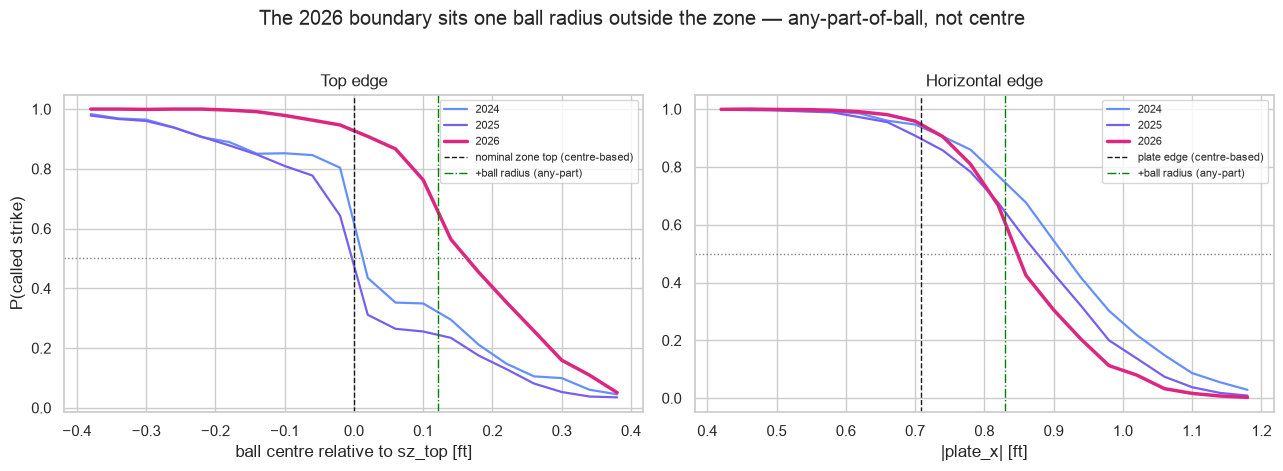

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for s, c in zip([2024, 2025, 2026], [PALETTE[1], PALETTE[2], PALETTE[3]]):
    g = tk[(tk.season == s) & (tk.plate_x_bat.abs() < 0.4)]
    d = (g.plate_z_mid - g.sz_top)
    bins = pd.cut(d, np.arange(-0.4, 0.42, 0.04))
    curve = g.groupby(bins, observed=True)['cs'].mean()
    ax[0].plot([i.mid for i in curve.index], curve.values, color=c, lw=2.5 if s == 2026 else 1.6, label=str(s))

    g2 = tk[(tk.season == s) & tk.plate_z_norm.between(0.25, 0.75)]
    bins2 = pd.cut(g2.plate_x_mid.abs(), np.arange(0.4, 1.22, 0.04))
    curve2 = g2.groupby(bins2, observed=True)['cs'].mean()
    ax[1].plot([i.mid for i in curve2.index], curve2.values, color=c, lw=2.5 if s == 2026 else 1.6, label=str(s))

for a in ax: a.axhline(0.5, color='grey', lw=1, ls=':')
ax[0].axvline(0, color='k', lw=1, ls='--', label='nominal zone top (centre-based)')
ax[0].axvline(BALL_R, color='green', lw=1, ls='-.', label='+ball radius (any-part)')
ax[0].set_xlabel('ball centre relative to sz_top [ft]'); ax[0].set_ylabel('P(called strike)')
ax[0].set_title('Top edge')
ax[1].axvline(D.PLATE_HALF_WIDTH_FT, color='k', lw=1, ls='--', label='plate edge (centre-based)')
ax[1].axvline(D.PLATE_HALF_WIDTH_FT + BALL_R, color='green', lw=1, ls='-.', label='+ball radius (any-part)')
ax[1].set_xlabel('|plate_x| [ft]'); ax[1].set_title('Horizontal edge')
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
fig.suptitle('The 2026 boundary sits one ball radius outside the zone — any-part-of-ball, not centre', y=1.02)
fig.tight_layout()

In [18]:
# Zone-edge sharpness. This MUST use one zone definition across eras: the ABS
# nominal zone is ~2.8 in shorter than the operator-set zone it replaced, so
# measuring "distance past the edge" in each era's own units makes 2026 look
# more generous than it really is. Recover height from the 2026 band (above)
# and apply the same zone to every season.
d = D.add_common_zone(df)
tk2 = d[~d.swing & d.outcome.isin(['ball', 'called_strike'])].copy()
tk2['cs'] = tk2.outcome.eq('called_strike')

def edge_of(g, top, bot):
    dx = g.plate_x_mid.abs() - D.PLATE_HALF_WIDTH_FT
    dz = np.maximum(g.plate_z_mid - g[top], g[bot] - g.plate_z_mid)
    return np.maximum(dx, dz)

tk2['edge_common'] = edge_of(tk2, 'zone_top', 'zone_bot')   # like-for-like
tk2['edge_own'] = edge_of(tk2, 'sz_top', 'sz_bot')          # each era's own units

rows = []
for s in SEASONS:
    g = tk2[tk2.season == s]
    rows.append({'season': s,
                 'own-era zone (confounded)': crossing(g.edge_own.to_numpy(), g.cs.to_numpy(), -0.25, 0.35),
                 'common height-derived zone': crossing(g.edge_common.to_numpy(), g.cs.to_numpy(), -0.25, 0.35)})
sharp = pd.DataFrame(rows).set_index('season').round(3)
sharp['ball radius'] = BALL_R
sharp

,own-era zone (confounded),common height-derived zone,ball radius
season,,,
2021,0.175,0.172,0.121
2022,0.169,0.171,0.121
2023,0.161,0.167,0.121
2024,0.161,0.176,0.121
2025,0.126,0.151,0.121
2026,0.122,0.122,0.121


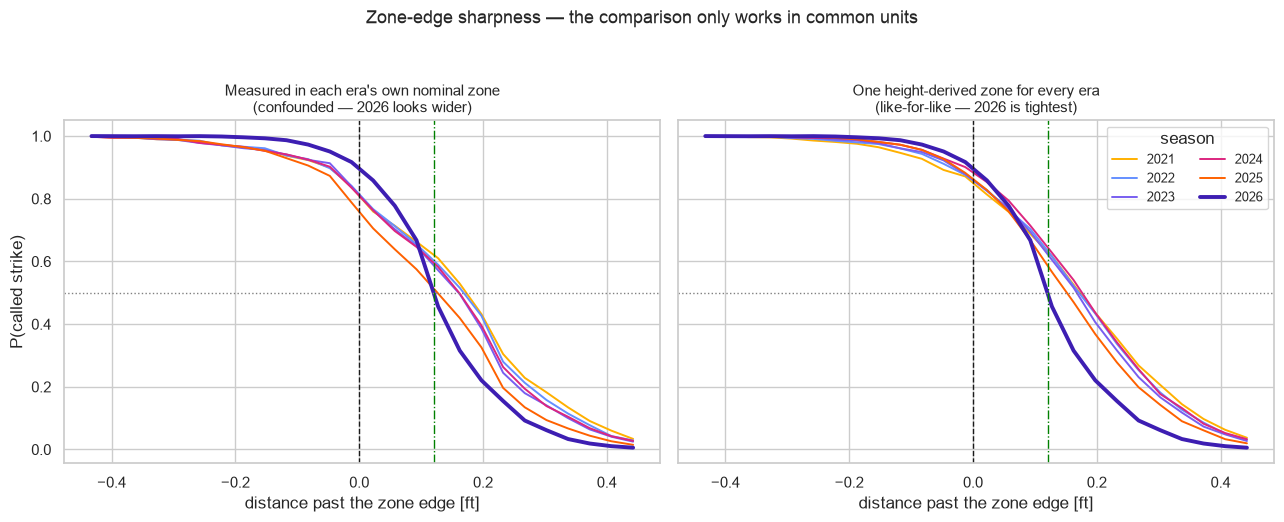

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
bins = np.arange(-0.45, 0.47, 0.035)
for col, a, title in [
        ('edge_own', ax[0], "Measured in each era's own nominal zone\n(confounded — 2026 looks wider)"),
        ('edge_common', ax[1], 'One height-derived zone for every era\n(like-for-like — 2026 is tightest)')]:
    for s, c in zip(SEASONS, PALETTE):
        g = tk2[tk2.season == s]
        curve = g.groupby(pd.cut(g[col], bins), observed=True)['cs'].mean()
        a.plot([i.mid for i in curve.index], curve.values, label=str(s),
               color=c, lw=2.8 if s == 2026 else 1.4)
    a.axvline(0, color='k', lw=1, ls='--')
    a.axvline(BALL_R, color='green', lw=1, ls='-.')
    a.axhline(0.5, color='grey', lw=1, ls=':')
    a.set_xlabel('distance past the zone edge [ft]')
    a.set_title(title, fontsize=11)
ax[0].set_ylabel('P(called strike)')
ax[1].legend(title='season', ncol=2, fontsize=9)
fig.suptitle('Zone-edge sharpness — the comparison only works in common units', y=1.04, fontsize=13)
fig.tight_layout()

In [20]:
# Effective called zone: the area over which a take is called a strike at least
# half the time, under the common zone definition.
cell = 0.05
areas = {}
for s in SEASONS:
    g = tk2[tk2.season == s]
    gx = np.digitize(g.plate_x_mid, np.arange(-1.3, 1.3, cell))
    gz = np.digitize(g.plate_z_mid - (g.zone_top + g.zone_bot) / 2, np.arange(-0.9, 0.9, cell))
    grid = (pd.DataFrame({'gx': gx, 'gz': gz, 'cs': g.cs.to_numpy()})
              .groupby(['gx', 'gz']).agg(rate=('cs', 'mean'), n=('cs', 'size')))
    areas[s] = grid.query('n >= 25 and rate >= 0.5').shape[0] * cell * cell
pd.Series(areas, name='effective called-strike zone [sq ft]').round(3).to_frame()

,effective called-strike zone [sq ft]
2021,3.183
2022,3.135
2023,3.088
2024,3.118
2025,2.985
2026,2.910


**§4 findings — the ABS band is confirmed exactly.** From 2026 a batter's
`sz_top`/`sz_bot` stop varying pitch to pitch (within-batter std 0.0000, against
0.073–0.098 in earlier seasons), and `sz_bot/sz_top` collapses to **0.5047 with
std 0.0000** across all hitters. 27.0/53.5 = 0.5047. The reported 27%–53.5%
height band is exact, and the plan's "verify before relying on it" flag is
cleared.

**ABS uses "any part of the ball", not the ball's centre.** The 2026 rules
define a strike as a pitch *any part of* which passes through the zone; ABS
evaluates that on a 2D plane at the midpoint of the plate rather than through
the 3D volume, but the ball-edge convention is unchanged from the rulebook. The
boundary table and plot above confirm it in the data: the 2026 50% crossing
sits **+0.163 ft past `sz_top`, +0.129 ft past `sz_bot`, and at 0.847 ft
horizontally**, against a ball radius of 0.121 ft and a predicted 0.829 ft. A
centre-based zone would have put those at 0.000 and 0.708. So the **same
ball-edge convention applies to every season**, and the cross-era zone
comparison in the table two cells up is a sensitivity check, not a correction.

**What did change is the nominal zone.** The ABS top sits **2.64 in lower**
than the operator-set top it replaced (3.215 ft vs 3.435 ft in 2025), and the
zone is ~2.8 in shorter overall. That, not a convention change, is what moves
the 2026 called-strike rates. It also explains the top-edge crossing looking
high in 2026: the nominal top dropped further than the called boundary did,
because only challenged pitches are actually corrected.

**The called zone genuinely narrowed — but only a like-for-like comparison
shows it.** Measured in each era's own nominal zone, 2026 looks *more*
generous. That is an artefact: the ABS zone is ~2.8 in shorter, so the same
physical pitch scores a larger "distance past the edge". Recovering batter
height from the 2026 band and applying one zone to every season reverses the
picture. The 50% boundary trends down — 0.172, 0.171, 0.167, 0.176, 0.151,
**0.122 ft** — and the effective called-strike area shrinks from 3.18 to
**2.91 sq ft**, an 8.6% contraction. 2026's 0.122 ft is the ball radius to
three decimals: under ABS
the called boundary converges on the true rulebook boundary, which is what a
correct system should do.

Height recovery is itself the cleanest confirmation of the band: `sz_top/0.535`
and `sz_bot/0.270` agree to **0.0000 in** for all 659 batters. It also yields a
noise-free zone for every season, since operator-set bounds carry a
within-batter std of 0.073–0.098 ft — worth using as the modelling feature.

**The lefty strike shrinks but survives.** The LHB–RHB gap on the outside edge
moves from −0.110 (2025) to −0.086 (2026), roughly a fifth of the way gone —
not the near-elimination a full robot zone would produce. That is the expected
signature of a *challenge* system: a handful of pitches per game are
challenged, so most calls are still human and still carry the historical bias.
It doubles as a check that the harmonization works, since a broken conversion
would have moved this erratically.

## §5 Decision structure and counterfactual overlap

**Decides:** the feature set, and whether any region needs propensity
trimming before the swing counterfactual is trusted.

In [21]:
def region(g):
    inz = D.in_rulebook_zone(g, ball_edge=True)
    near = (g.plate_x_bat.abs() <= 1.15) & g.plate_z_norm.between(-0.35, 1.35)
    return pd.Series(np.where(inz, 'zone', np.where(near, 'shadow', 'chase')), index=g.index)

df['region'] = region(df)
ov = (df.groupby(['region', 'count'], observed=True)
        .agg(pitches=('swing', 'size'), swings=('swing', 'sum')))
ov['takes'] = ov.pitches - ov.swings
ov['swing%'] = (ov.swings / ov.pitches * 100).round(1)
ov['min action n'] = ov[['swings', 'takes']].min(axis=1)
print('Counterfactual support: the scarcer action in each cell.')
print(f"thinnest cell: {ov['min action n'].min():,} observations")
ov.sort_values('min action n').head(12)

Counterfactual support: the scarcer action in each cell.
thinnest cell: 105 observations


pitches  swings  takes  swing%  min action n
region count                                              
chase  3-0       7077     105   6972     1.5           105
shadow 3-0      11647     685  10962     5.9           685
chase  3-1      15563    1959  13604    12.6          1959
       2-0      26573    2720  23853    10.2          2720
zone   3-0      24637    3334  21303    13.5          3334
chase  2-1      46357    8250  38107    17.8          8250
zone   0-2      78853   69292   9561    87.9          9561
shadow 3-1      25147    9961  15186    39.6          9961
zone   3-2     109604   99331  10273    90.6         10273
chase  1-0      92333   11230  81103    12.2         11230
       3-2      42222   11350  30872    26.9         11350
shadow 2-0      39855   12650  27205    31.7         12650

Text(0.5, 1.02, 'Swing rate by location and strikes — batter frame')

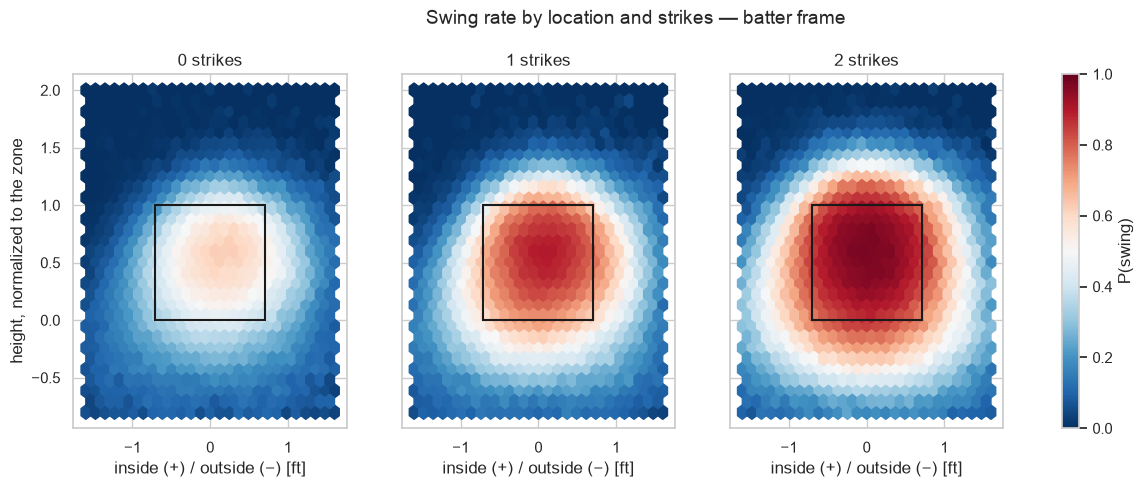

In [22]:
# Swing rate surface by count -- the decision behaviour the model must explain.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, k in zip(axes, [0, 1, 2]):
    s = df[df.strikes == k]
    hb = ax.hexbin(s.plate_x_bat, s.plate_z_norm, C=s.swing.astype(float),
                   gridsize=26, extent=[-1.6, 1.6, -0.8, 2.0], cmap='RdBu_r', vmin=0, vmax=1)
    ax.add_patch(plt.Rectangle((-D.PLATE_HALF_WIDTH_FT, 0), 2*D.PLATE_HALF_WIDTH_FT, 1,
                               fill=False, color='k', lw=1.5))
    ax.set_title(f'{k} strikes'); ax.set_xlabel('inside (+) / outside (−) [ft]')
axes[0].set_ylabel('height, normalized to the zone')
fig.colorbar(hb, ax=axes, label='P(swing)')
fig.suptitle('Swing rate by location and strikes — batter frame', y=1.02, fontsize=14)

In [23]:
# Outcome mix given a swing: the target of Track B's three-class sub-model.
sw = df[df.swing].copy()
sw['result'] = np.select(
    [sw.outcome.eq('swinging_strike'), sw.outcome.eq('foul')], ['whiff', 'foul'], default='in play')
mix = (sw.groupby(['region', 'strikes'], observed=True)['result']
         .value_counts(normalize=True).unstack().round(3) * 100)
mix['n'] = sw.groupby(['region', 'strikes'], observed=True).size()
mix

result          foul  in play  whiff       n
region strikes                              
chase  0        22.1     10.5   67.4   37023
       1        22.7     12.6   64.7   58176
       2        26.4     17.2   56.5  103683
shadow 0        34.3     26.2   39.6  135200
       1        35.4     29.2   35.4  184266
       2        39.0     32.0   28.9  238135
zone   0        40.4     41.8   17.7  408309
       1        40.5     42.8   16.7  432612
       2        41.1     44.4   14.4  416874

**§5 findings — overlap is good except on 3-0.** Most region × count cells
carry thousands of both actions, but the tail is thinner than expected and the
thinnest cell holds just **105 swings** (chase, 3-0), followed by 685 (shadow,
3-0). On 3-0 a batter almost never offers at anything off the plate, so the
swing counterfactual there rests on very little data — and 3-0 is exactly where
take value is largest, so errors are consequential.

This is the one place the plan's assumption of uniform support fails. Options,
in order of preference: flag 3-0 chase/shadow cells in the diagnostics and
report their uncertainty rather than trimming; or pool 3-0 with 2-0 for the
swing sub-model only; or trim on propensity. Decide once the bootstrap spread
from `IMPROVEMENT_PLAN.md` §4.2 is measured — if Δ does not flip sign there, the
thin support is tolerable.

Everywhere else support is ample, including the intuitively worrying cells
(zone/0-2 takes: 9,561; zone/3-2 takes: 10,273).

The swing-rate surface

## §6 Hitter-level feasibility

**Decides:** qualification thresholds, prior-window length, and whether a
per-hitter contact-quality surface is estimable at all.

In [24]:
bat = (df.groupby(['season', 'batter'], observed=True)
         .agg(pitches=('swing', 'size'),
              bip=('outcome', lambda s: s.isin(['single','double','triple','home_run','field_out','field_error']).sum()))
         .reset_index())
feas = bat.groupby('season').agg(
    batters=('batter', 'size'),
    p500=('pitches', lambda s: (s >= 500).sum()),
    bip60=('bip', lambda s: (s >= 60).sum()),
    bip150=('bip', lambda s: (s >= 150).sum()),
    median_bip=('bip', 'median'))
feas

,batters,p500,bip60,bip150,median_bip
season,,,,,
2021,1049,437,472,328,36.0
2022,693,435,474,334,139.0
2023,656,432,470,343,157.5
2024,651,425,458,343,166.0
2025,673,419,467,327,140.0
2026,659,423,465,329,149.0


In [25]:
# The binding constraint on a per-hitter contact-quality surface is balls in
# play PER LOCATION REGION, not per season.
q = bat[(bat.season == 2025) & (bat.pitches >= 500)].batter
bip_rows = df[(df.season == 2025) & df.batter.isin(q) &
              df.outcome.isin(['single','double','triple','home_run','field_out','field_error'])].copy()
bip_rows['cell'] = (pd.cut(bip_rows.plate_x_bat, np.linspace(-1.2, 1.2, 5)).astype(str) + '|' +
                    pd.cut(bip_rows.plate_z_norm, np.linspace(-0.3, 1.5, 5)).astype(str))
per_cell = bip_rows.groupby(['batter', 'cell'], observed=True).size()
print('balls in play per qualified batter per location cell (4x4 grid), 2025:')
print(per_cell.describe(percentiles=[.1, .25, .5, .75]).round(1).to_string())
print(f'\ncells with < 10 BIP: {(per_cell < 10).mean():.1%} of batter-cells')

balls in play per qualified batter per location cell (4x4 grid), 2025:
count    5810.0
mean       19.4
std        19.7
min         1.0
10%         2.0
25%         5.0
50%        13.0
75%        27.8
max       123.0

cells with < 10 BIP: 41.2% of batter-cells


In [26]:
# Batters shared between consecutive seasons -- the sample for each
# year-over-year reliability pair.
qual = {s: set(g[g.pitches >= 500].batter) for s, g in bat.groupby('season')}
pairs = [(a, b) for a, b in zip(sorted(qual)[:-1], sorted(qual)[1:])]
print('qualified batters (>=500 pitches) shared across consecutive seasons:')
for a, b in pairs:
    print(f'  {a} -> {b}: {len(qual[a] & qual[b]):3d}  '
          f'(of {len(qual[a])} and {len(qual[b])})')

qualified batters (>=500 pitches) shared across consecutive seasons:
  2021 -> 2022: 330  (of 437 and 435)
  2022 -> 2023: 325  (of 435 and 432)
  2023 -> 2024: 332  (of 432 and 425)
  2024 -> 2025: 326  (of 425 and 419)
  2025 -> 2026: 322  (of 419 and 423)


          mean     std     min     max
season                                
2021    0.4326  0.0214  0.3506  0.4956
2022    0.4292  0.0224  0.3554  0.5055
2023    0.4334  0.0239  0.3459  0.5053
2024    0.4393  0.0224  0.3688  0.5044
2025    0.4508  0.0242  0.3674  0.5205
2026    0.4293  0.0198  0.3724  0.4879


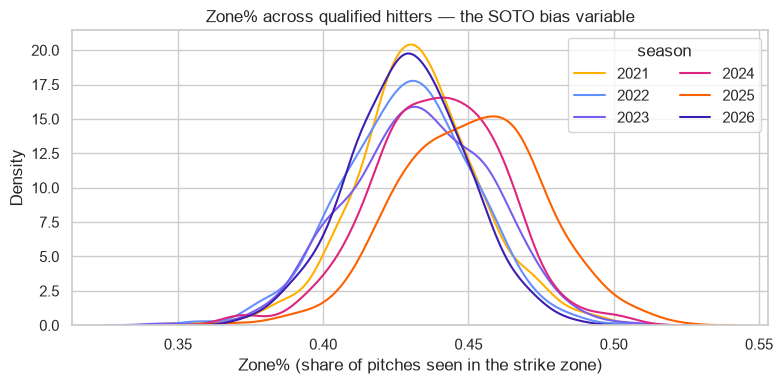

In [27]:
# Zone%: the variable that retired SOTO. Establish the spread across hitters so
# the later acceptance test has a baseline.
z = (df[df.pitches_idx.notna()] if 'pitches_idx' in df else df)
zone_pct = (df.assign(inz=D.in_rulebook_zone(df, ball_edge=True))
              .groupby(['season', 'batter'], observed=True)
              .agg(inz=('inz', 'mean'), n=('inz', 'size')).query('n >= 500'))
print(zone_pct.groupby('season')['inz'].describe()[['mean', 'std', 'min', 'max']].round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
for s, c in zip(SEASONS, PALETTE):
    sns.kdeplot(zone_pct.loc[s, 'inz'], ax=ax, label=str(s), color=c)
ax.set_xlabel('Zone% (share of pitches seen in the strike zone)')
ax.set_title('Zone% across qualified hitters — the SOTO bias variable')
ax.legend(title='season', ncol=2)
fig.tight_layout()

**§6 findings — one season cannot support a per-hitter surface.** Roughly 425
hitters clear 500 pitches per season and ~330 clear 150 balls in play, and
322–332 qualified hitters are shared by each consecutive season pair, so every
year-over-year reliability estimate rests on a healthy sample.

The decisive number is balls in play per hitter *per location cell*: on a 4×4
grid the median is **13**, the 25th percentile is 5, and **41% of batter-cells
hold fewer than 10**. A per-hitter contact-quality surface estimated from a
single season is therefore mostly noise, which also explains why the v2 hull —
built on the top 5% of one season's balls in play, so a handful of points —
destabilised the metric. This settles `IMPROVEMENT_PLAN.md` §3.4 in favour of
the **shrunken continuous surface over a multi-season prior window**, not the
binary hull and not a single-season estimate.

Zone% has a standard deviation of ~0.022 across qualified hitters and a range
of roughly 0.35–0.52. That spread is the room available for the opportunity
bias that retired SOTO, and the later Zone%-correlation test is measured
against it.

## §7 Baseline outcome relationships

The sanity plots. These must look right before any model output is trusted.

In [28]:
rv = D.run_value_table(df, years=range(2021, 2025))
show = ['ball', 'called_strike', 'foul', 'swinging_strike', 'single', 'home_run', 'field_out']
tbl = rv.unstack('count')[['0-0','1-0','2-0','3-0','0-1','1-1','2-1','3-1','0-2','1-2','2-2','3-2']]
tbl.loc[[s for s in show if s in tbl.index]].round(3)

count,0-0,1-0,2-0,3-0,0-1,1-1,2-1,3-1,0-2,1-2,2-2,3-2
outcome,,,,,,,,,,,,
ball,0.037,0.061,0.112,0.132,0.028,0.050,0.105,0.200,0.021,0.040,0.096,0.287
called_strike,-0.041,-0.050,-0.061,-0.069,-0.057,-0.064,-0.074,-0.084,-0.168,-0.190,-0.230,-0.327
foul,-0.041,-0.050,-0.061,-0.064,-0.057,-0.064,-0.074,-0.084,0.000,0.000,-0.000,-0.000
swinging_strike,-0.042,-0.050,-0.061,-0.063,-0.057,-0.064,-0.074,-0.084,-0.167,-0.189,-0.230,-0.325
single,0.420,0.399,0.341,0.270,0.473,0.447,0.402,0.294,0.537,0.515,0.477,0.380
home_run,1.522,1.494,1.421,1.356,1.568,1.550,1.497,1.405,1.630,1.621,1.584,1.498
field_out,-0.253,-0.296,-0.358,-0.454,-0.219,-0.247,-0.297,-0.404,-0.164,-0.185,-0.225,-0.321


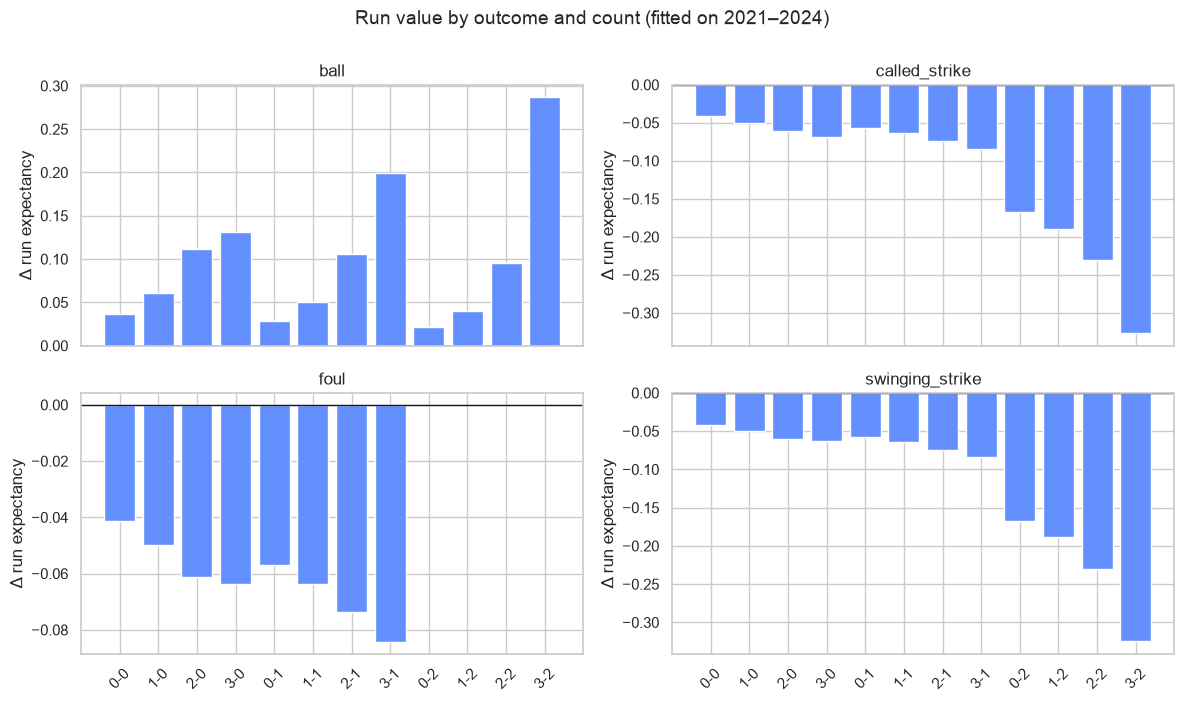

In [29]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for a, o in zip(ax.flat, ['ball', 'called_strike', 'foul', 'swinging_strike']):
    r = rv.loc[o].reindex(['0-0','1-0','2-0','3-0','0-1','1-1','2-1','3-1','0-2','1-2','2-2','3-2'])
    a.bar(range(len(r)), r.values, color=PALETTE[1])
    a.set_xticks(range(len(r))); a.set_xticklabels(r.index, rotation=45)
    a.axhline(0, color='k', lw=1); a.set_title(o); a.set_ylabel('Δ run expectancy')
fig.suptitle('Run value by outcome and count (fitted on 2021–2024)', y=1.0, fontsize=14)
fig.tight_layout()

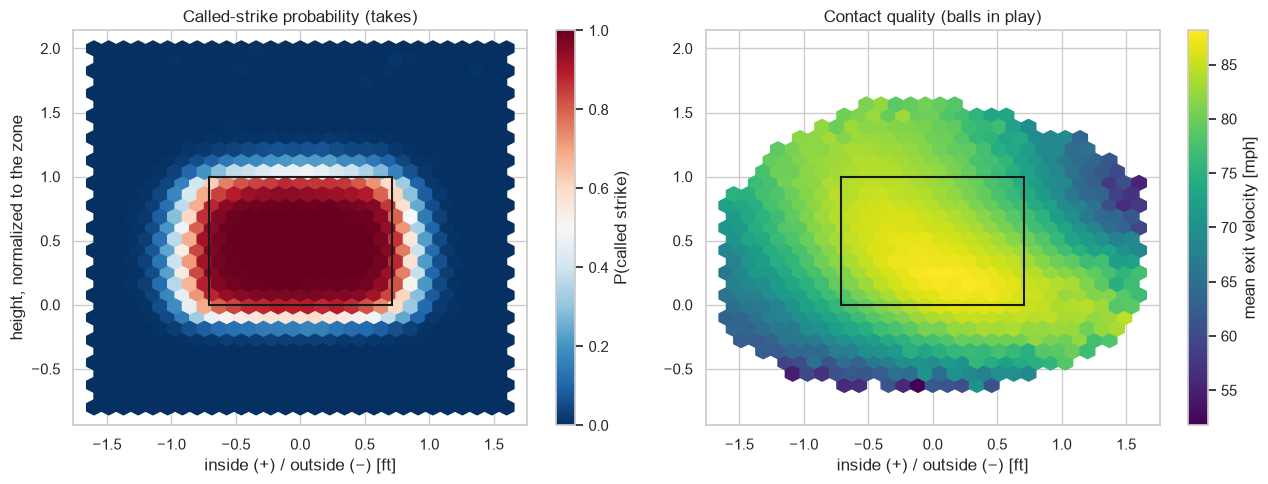

In [30]:
# Called-strike probability and contact quality over the plate, batter frame.
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
t = df[~df.swing & df.outcome.isin(['ball', 'called_strike'])]
h0 = ax[0].hexbin(t.plate_x_bat, t.plate_z_norm, C=t.outcome.eq('called_strike').astype(float),
                  gridsize=28, extent=[-1.6, 1.6, -0.8, 2.0], cmap='RdBu_r', vmin=0, vmax=1)
fig.colorbar(h0, ax=ax[0], label='P(called strike)')
ax[0].set_title('Called-strike probability (takes)')

b = df[df.launch_speed.notna()]
h1 = ax[1].hexbin(b.plate_x_bat, b.plate_z_norm, C=b.launch_speed,
                  gridsize=28, extent=[-1.6, 1.6, -0.8, 2.0], cmap='viridis', mincnt=40)
fig.colorbar(h1, ax=ax[1], label='mean exit velocity [mph]')
ax[1].set_title('Contact quality (balls in play)')
for a in ax:
    a.add_patch(plt.Rectangle((-D.PLATE_HALF_WIDTH_FT, 0), 2*D.PLATE_HALF_WIDTH_FT, 1,
                              fill=False, color='k', lw=1.5))
    a.set_xlabel('inside (+) / outside (−) [ft]')
ax[0].set_ylabel('height, normalized to the zone')
fig.tight_layout()

## Decisions carried forward

| § | Decision |
|---|---|
| 1 | Drop untracked pitches (~0.4%, missing jointly, unbiased w.r.t. the decision). Exclude `automatic_ball`/`automatic_strike` as non-decisions, counted explicitly. `bat_speed` usable only as a 2025–2026 prior. |
| 2 | Apply `drop_pitchers_batting()` to every season. 2021 loses 402 batters; 2022+ loses 16–30. |
| 3 | Keep the context-neutral `(outcome, count)` target. Fit the run-value table **once** on training seasons — drift is ≤0.014 runs, so no recency weighting. Separate `field_error` (+0.461) from `field_out` (−0.250). |
| 4 | ABS band confirmed as exactly 27%–53.5% of height. **Ball-edge convention for every season** — ABS is any-part-of-the-ball, verified against the empirical boundary. The real 2026 change is a nominal zone 2.64 in lower at the top. The lefty strike shrinks by only ~20%, so handedness stays in the feature set even for 2026. |
| 5 | Overlap is sufficient except **3-0 chase/shadow** (105 and 685 swings). Flag those cells and report uncertainty; revisit after the bootstrap check. |
| 6 | ~425 hitters qualify per season; 322–332 shared per consecutive pair. 41% of batter-cells hold <10 balls in play, so the per-hitter surface **must** be shrunk and pooled over a multi-season window — settles §3.4 against the binary hull. |